<a href="https://colab.research.google.com/github/atikhasan007/Machine-Learning/blob/main/xgboostcp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import all necessary library**

In [1]:
# Basic Python Libraries
import os
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#  Statistical Analysis
from scipy import stats

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# Reproducibility
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)




In [2]:
# Device Configuration
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.11.0+cu128
Device: cuda


**Dataset Load**

In [3]:
import pandas as pd

df_2025 = pd.read_csv(
    "/content/Alice_Springs_2025.csv",
    engine="python",
    on_bad_lines="skip"
)

df_2026 = pd.read_csv(
    "/content/Alice_Springs_2026.csv",
    engine="python",
    on_bad_lines="skip"
)

print("2025 shape:", df_2025.shape)
print("2026 shape:", df_2026.shape)

2025 shape: (23666, 210)
2026 shape: (12090, 210)


In [4]:
common_cols = set(df_2025.columns) & set(df_2026.columns)

print("2025 columns:", len(df_2025.columns))
print("2026 columns:", len(df_2026.columns))
print("Common columns:", len(common_cols))
print("Merged columns:", len(set(df_2025.columns) | set(df_2026.columns)))

2025 columns: 210
2026 columns: 210
Common columns: 14
Merged columns: 406


In [5]:
# common column
print(sorted(common_cols))

['100_DKA_M1_A_Phase_Active_Energy_Delivered_Received', '100_DKA_M1_A_Phase_Active_Power', '100_DKA_M1_A_Phase_Current_Phase_Average', '100_DKA_M1_A_Phase_Performance_Ratio', '103_DKA_M1_B_Phase_Active_Energy_Delivered_Received', '103_DKA_M1_B_Phase_Active_Power', '103_DKA_M1_B_Phase_Current_Phase_Average', '105_DKA_M1_C_Phase_Active_Energy_Delivered_Received', '105_DKA_M1_C_Phase_Active_Power', '105_DKA_M1_C_Phase_Current_Phase_Average', '205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Energy_Delivered_Received', '205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Power', '205_Archived_DKA_M15_BPhase_UMG_QCells_Current_Phase_Average', 'timestamp']


**Dataset marge**

In [6]:
# Merge datasets
df = pd.concat(
    [df_2025, df_2026],
    axis=0,
    ignore_index=True
)

In [7]:
# check the marge dataset shape
df.shape

(35756, 406)

In [8]:
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

0: timestamp
1: 205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Energy_Delivered_Received
2: 205_Archived_DKA_M15_BPhase_UMG_QCells_Current_Phase_Average
3: 205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Power
4: 239_DKA_Totals_BESS_Reactive_Power
5: 239_DKA_Totals_BESS_Active_Power
6: 239_DKA_Totals_BESS_Apparent_Power
7: 239_DKA_Totals_BESS_State_of_Charge
8: 242_DKA_Totals_Grid_Reactive_Power
9: 242_DKA_Totals_Grid_Active_Power
10: 242_DKA_Totals_Grid_Apparent_Power
11: 241_DKA_Totals_PV_Reactive_Power
12: 241_DKA_Totals_PV_Active_Power
13: 241_DKA_Totals_PV_Apparent_Power
14: 240_DKA_Totals_Site_Demand_Reactive_Power
15: 240_DKA_Totals_Site_Demand_Active_Power
16: 240_DKA_Totals_Site_Demand_Apparent_Power
17: 100_DKA_M1_A_Phase_Active_Energy_Delivered_Received
18: 100_DKA_M1_A_Phase_Current_Phase_Average
19: 100_DKA_M1_A_Phase_Active_Power
20: 100_DKA_M1_A_Phase_Performance_Ratio
21: 103_DKA_M1_B_Phase_Active_Energy_Delivered_Received
22: 103_DKA_M1_B_Phase_Current_Phase_Average
23: 1

In [9]:
# feature selection
target_col = "241_DKA_Totals_PV_Active_Power"

weather_features = [
    "101_DKA_WeatherStation_Global_Horizontal_Radiation",
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Diffuse_Horizontal_Radiation",
    "101_DKA_WeatherStation_Wind_Speed",
    "101_DKA_WeatherStation_Wind_Direction",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "101_DKA_WeatherStation_Weather_Daily_Rainfall",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
]

# ডেটাসেটে আসলে আছে কিনা যাচাই
weather_features = [c for c in weather_features if c in df.columns]
print(weather_features)

['101_DKA_WeatherStation_Global_Horizontal_Radiation', '101_DKA_WeatherStation_Radiation_Global_Tilted', '101_DKA_WeatherStation_Weather_Temperature_Celsius', '101_DKA_WeatherStation_Diffuse_Horizontal_Radiation', '101_DKA_WeatherStation_Wind_Speed', '101_DKA_WeatherStation_Wind_Direction', '101_DKA_WeatherStation_Weather_Relative_Humidity', '101_DKA_WeatherStation_Weather_Daily_Rainfall', '101_DKA_WeatherStation_Radiation_Diffuse_Tilted']


In [10]:
corr_df = df[weather_features + [target_col]].corr()

print("Correlation with target (sorted):")
print(corr_df[target_col].sort_values(ascending=False))

Correlation with target (sorted):
241_DKA_Totals_PV_Active_Power                         1.000000
101_DKA_WeatherStation_Global_Horizontal_Radiation     0.995614
101_DKA_WeatherStation_Radiation_Global_Tilted         0.990497
101_DKA_WeatherStation_Radiation_Diffuse_Tilted        0.742915
101_DKA_WeatherStation_Weather_Temperature_Celsius     0.647080
101_DKA_WeatherStation_Diffuse_Horizontal_Radiation    0.634349
101_DKA_WeatherStation_Wind_Direction                  0.021753
101_DKA_WeatherStation_Weather_Daily_Rainfall         -0.116494
101_DKA_WeatherStation_Weather_Relative_Humidity      -0.380394
101_DKA_WeatherStation_Wind_Speed                           NaN
Name: 241_DKA_Totals_PV_Active_Power, dtype: float64


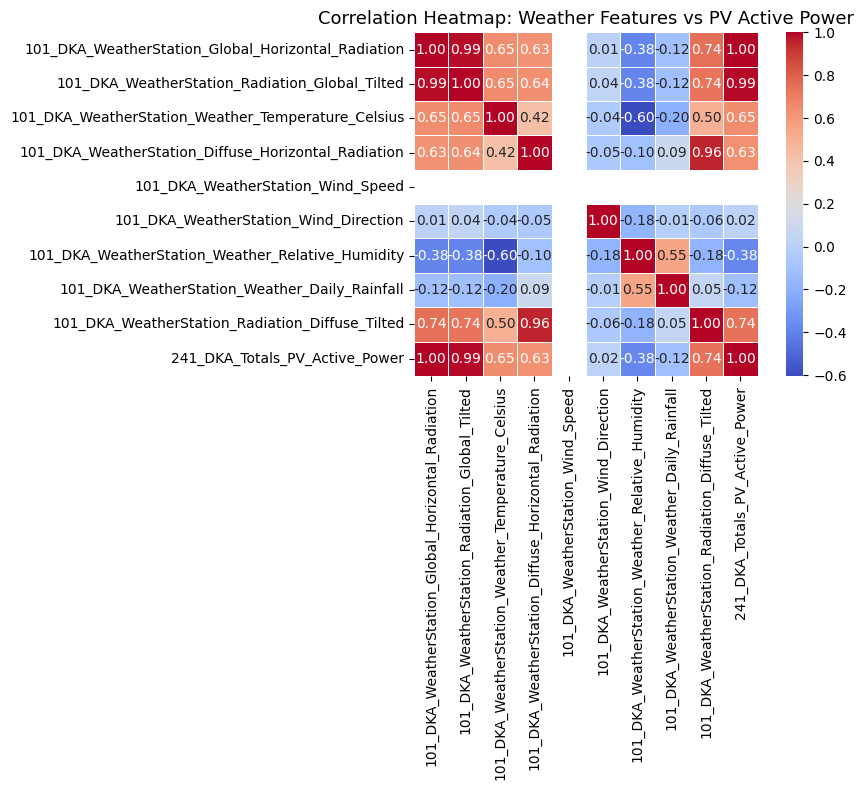

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Weather Features vs PV Active Power", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [12]:
final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Global_Horizontal_Radiation",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",  # optional
    "101_DKA_WeatherStation_Diffuse_Horizontal_Radiation",  # optional
]

# বাদ দেওয়া হলো:
# Wind_Direction (0.03), Weather_Daily_Rainfall (-0.03), Wind_Speed (NaN)

In [13]:
final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",   # target corr: 0.99 — সবচেয়ে শক্তিশালী
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",  # target corr: 0.66 — diffuse light effect
    "101_DKA_WeatherStation_Weather_Temperature_Celsius", # target corr: 0.41 — thermal effect
    "101_DKA_WeatherStation_Weather_Relative_Humidity",   # target corr: -0.45 — moisture/cloud effect
]

In [14]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

In [15]:
# ==============================
# 1. Target and features
# ==============================

target_col_original = "241_DKA_Totals_PV_Active_Power"
target_col = "pv_power"

final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

In [16]:
# ==============================
# 2. Timestamp conversion
# ==============================

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Remove invalid timestamps
df = df.dropna(subset=["timestamp"])

In [17]:
# ==============================
# 3. Sort chronologically
# ==============================

df = df.sort_values("timestamp").reset_index(drop=True)

In [18]:
# ==============================
# 4. Remove duplicate timestamps
# ==============================

print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

df = df.drop_duplicates(
    subset=["timestamp"],
    keep="first"
).reset_index(drop=True)

print("After duplicate removal:", df.shape)

Duplicate timestamps: 0
After duplicate removal: (35756, 406)


In [19]:
# ==============================
# 5. Rename target
# ==============================

df = df.rename(columns={
    target_col_original: target_col
})

In [20]:
# ==============================
# 6. Keep only required columns
# ==============================

required_columns = ["timestamp", target_col] + final_features

df = df[required_columns].copy()

print(df.shape)
print(df.columns.tolist())

(35756, 6)
['timestamp', 'pv_power', '101_DKA_WeatherStation_Radiation_Global_Tilted', '101_DKA_WeatherStation_Radiation_Diffuse_Tilted', '101_DKA_WeatherStation_Weather_Temperature_Celsius', '101_DKA_WeatherStation_Weather_Relative_Humidity']


In [21]:
# ==============================
# 7. Chronological split
# ==============================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

In [22]:
print("Train:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())

print("\nValidation:")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())

print("\nTest:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())

Train:
2025-01-01 00:00:00 → 2026-01-05 17:30:00

Validation:
2026-01-05 17:35:00 → 2026-01-24 08:35:00

Test:
2026-01-24 08:40:00 → 2026-02-11 23:55:00


**missing value handelling**

In [23]:
target_col = "pv_power"

final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

required_cols = ["timestamp", target_col] + final_features

print(df[required_cols].isna().sum())

timestamp                                                 0
pv_power                                              12120
101_DKA_WeatherStation_Radiation_Global_Tilted        12190
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       12190
101_DKA_WeatherStation_Weather_Temperature_Celsius    18172
101_DKA_WeatherStation_Weather_Relative_Humidity      18172
dtype: int64


In [24]:
# Missing percentage
missing_summary = pd.DataFrame({
    "missing_count": df[required_cols].isna().sum(),
    "missing_percent": (df[required_cols].isna().mean() * 100).round(2)
})

print(missing_summary)

                                                    missing_count  \
timestamp                                                       0   
pv_power                                                    12120   
101_DKA_WeatherStation_Radiation_Global_Tilted              12190   
101_DKA_WeatherStation_Radiation_Diffuse_Tilted             12190   
101_DKA_WeatherStation_Weather_Temperature_Celsius          18172   
101_DKA_WeatherStation_Weather_Relative_Humidity            18172   

                                                    missing_percent  
timestamp                                                      0.00  
pv_power                                                      33.90  
101_DKA_WeatherStation_Radiation_Global_Tilted                34.09  
101_DKA_WeatherStation_Radiation_Diffuse_Tilted               34.09  
101_DKA_WeatherStation_Weather_Temperature_Celsius            50.82  
101_DKA_WeatherStation_Weather_Relative_Humidity              50.82  


In [25]:
for col in required_cols:
    if col == "timestamp":
        continue

    is_missing = df[col].isna()

    groups = (is_missing != is_missing.shift()).cumsum()

    gap_sizes = (
        is_missing.groupby(groups)
        .sum()
        .sort_values(ascending=False)
    )

    print(f"\n{col}")
    print("Largest consecutive missing rows:", int(gap_sizes.iloc[0]))


pv_power
Largest consecutive missing rows: 12090

101_DKA_WeatherStation_Radiation_Global_Tilted
Largest consecutive missing rows: 12091

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
Largest consecutive missing rows: 12091

101_DKA_WeatherStation_Weather_Temperature_Celsius
Largest consecutive missing rows: 12091

101_DKA_WeatherStation_Weather_Relative_Humidity
Largest consecutive missing rows: 12091


In [26]:
cols_to_check = ["pv_power"] + final_features

for col in cols_to_check:
    missing_idx = df.index[df[col].isna()]

    print(f"\n{col}")
    print("First missing:", df.loc[missing_idx.min(), "timestamp"])
    print("Last missing :", df.loc[missing_idx.max(), "timestamp"])


pv_power
First missing: 2025-01-02 03:35:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Radiation_Global_Tilted
First missing: 2025-01-04 09:35:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
First missing: 2025-01-04 09:35:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Weather_Temperature_Celsius
First missing: 2025-01-04 21:00:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Weather_Relative_Humidity
First missing: 2025-01-04 21:00:00
Last missing : 2026-02-11 23:55:00


In [27]:
import pandas as pd

cols_to_check = ["pv_power"] + final_features

for col in cols_to_check:

    is_missing = df[col].isna()

    # Consecutive missing groups
    groups = (is_missing != is_missing.shift()).cumsum()

    missing_blocks = (
        df.loc[is_missing]
        .groupby(groups[is_missing])
        .agg(
            start=("timestamp", "min"),
            end=("timestamp", "max"),
            rows=("timestamp", "size")
        )
    )

    # Largest missing block
    largest_block = missing_blocks.sort_values(
        "rows",
        ascending=False
    ).iloc[0]

    duration = (
        largest_block["end"] - largest_block["start"]
    )

    print(f"\n{col}")
    print("Start   :", largest_block["start"])
    print("End     :", largest_block["end"])
    print("Rows    :", largest_block["rows"])
    print("Duration:", duration)


pv_power
Start   : 2026-01-01 00:00:00
End     : 2026-02-11 23:55:00
Rows    : 12090
Duration: 41 days 23:55:00

101_DKA_WeatherStation_Radiation_Global_Tilted
Start   : 2025-03-24 04:25:00
End     : 2026-02-11 23:55:00
Rows    : 12091
Duration: 324 days 19:30:00

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
Start   : 2025-03-24 04:25:00
End     : 2026-02-11 23:55:00
Rows    : 12091
Duration: 324 days 19:30:00

101_DKA_WeatherStation_Weather_Temperature_Celsius
Start   : 2025-03-24 04:25:00
End     : 2026-02-11 23:55:00
Rows    : 12091
Duration: 324 days 19:30:00

101_DKA_WeatherStation_Weather_Relative_Humidity
Start   : 2025-03-24 04:25:00
End     : 2026-02-11 23:55:00
Rows    : 12091
Duration: 324 days 19:30:00


In [28]:
# Large continuous missing period
start_gap = pd.Timestamp("2026-01-02 00:00:00")
end_gap = pd.Timestamp("2026-02-11 23:55:00")

# Remove the complete missing block
df = df[
    ~df["timestamp"].between(start_gap, end_gap)
].copy()

# Reset index
df = df.reset_index(drop=True)

print("New shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End  :", df["timestamp"].max())

New shape: (23954, 6)
Start: 2025-01-01 00:00:00
End  : 2026-01-01 23:55:00


In [29]:
required_cols = ["timestamp", "pv_power"] + final_features

missing_summary = pd.DataFrame({
    "missing_count": df[required_cols].isna().sum(),
    "missing_percent": (
        df[required_cols].isna().mean() * 100
    ).round(2)
})

print(missing_summary)

                                                    missing_count  \
timestamp                                                       0   
pv_power                                                      318   
101_DKA_WeatherStation_Radiation_Global_Tilted                388   
101_DKA_WeatherStation_Radiation_Diffuse_Tilted               388   
101_DKA_WeatherStation_Weather_Temperature_Celsius           6370   
101_DKA_WeatherStation_Weather_Relative_Humidity             6370   

                                                    missing_percent  
timestamp                                                      0.00  
pv_power                                                       1.33  
101_DKA_WeatherStation_Radiation_Global_Tilted                 1.62  
101_DKA_WeatherStation_Radiation_Diffuse_Tilted                1.62  
101_DKA_WeatherStation_Weather_Temperature_Celsius            26.59  
101_DKA_WeatherStation_Weather_Relative_Humidity              26.59  


In [30]:
cols_to_check = ["pv_power"] + final_features

for col in cols_to_check:

    is_missing = df[col].isna()

    groups = (is_missing != is_missing.shift()).cumsum()

    missing_blocks = (
        df.loc[is_missing]
        .groupby(groups[is_missing])
        .agg(
            start=("timestamp", "min"),
            end=("timestamp", "max"),
            rows=("timestamp", "size")
        )
        .sort_values("rows", ascending=False)
    )

    print(f"\n{'='*70}")
    print(col)
    print(missing_blocks.head(10))


pv_power
                       start                 end  rows
pv_power                                              
48       2026-01-01 00:00:00 2026-01-01 23:55:00   288
6        2025-01-07 03:35:00 2025-01-07 03:40:00     2
14       2025-01-11 03:35:00 2025-01-11 03:40:00     2
12       2025-01-10 03:40:00 2025-01-10 03:45:00     2
42       2025-03-17 10:40:00 2025-03-17 10:45:00     2
40       2025-03-06 05:30:00 2025-03-06 05:35:00     2
38       2025-02-22 03:40:00 2025-02-22 03:45:00     2
46       2025-03-19 04:05:00 2025-03-19 04:10:00     2
16       2025-01-12 02:30:00 2025-01-12 02:30:00     1
10       2025-01-09 03:45:00 2025-01-09 03:45:00     1

101_DKA_WeatherStation_Radiation_Global_Tilted
                                                             start  \
101_DKA_WeatherStation_Radiation_Global_Tilted                       
72                                             2025-03-24 04:25:00   
8                                              2025-01-08 09:05:00   
34

In [31]:
# ============================================
# Missing Value Handling
# ============================================

target_col = "pv_power"

weather_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

# --------------------------------------------
# 1. Remove rows where target is missing
# --------------------------------------------

df = df.dropna(subset=[target_col]).copy()

print("After removing missing pv_power:")
print(df.shape)


# --------------------------------------------
# 2. Interpolate only small gaps
#    Maximum 1 hour = 12 consecutive 5-min rows
# --------------------------------------------

df[weather_features] = df[weather_features].interpolate(
    method="linear",
    limit=11,
    limit_direction="both"
)


# --------------------------------------------
# 3. Remove rows where large weather gaps
#    are still missing
# --------------------------------------------

df = df.dropna(
    subset=weather_features
).reset_index(drop=True)


# --------------------------------------------
# 4. Final missing-value check
# --------------------------------------------

print("\nFinal missing values:")
print(df[["timestamp", target_col] + weather_features].isna().sum())

print("\nFinal dataset shape:")
print(df.shape)

After removing missing pv_power:
(23636, 6)

Final missing values:
timestamp                                             0
pv_power                                              0
101_DKA_WeatherStation_Radiation_Global_Tilted        0
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       0
101_DKA_WeatherStation_Weather_Temperature_Celsius    0
101_DKA_WeatherStation_Weather_Relative_Humidity      0
dtype: int64

Final dataset shape:
(17606, 6)


In [32]:
# Check chronological order
is_sorted = df["timestamp"].is_monotonic_increasing

print("Chronological:", is_sorted)

Chronological: True


In [33]:
# Check duplicate timestamps
duplicate_count = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_count)

Duplicate timestamps: 0


In [34]:
# Check timestamp intervals
time_diff = df["timestamp"].diff().dropna()

print(time_diff.value_counts().head(10))

timestamp
0 days 00:05:00     17586
0 days 00:10:00        10
0 days 00:15:00         4
20 days 23:40:00        1
0 days 00:10:01         1
0 days 00:04:59         1
0 days 00:15:19         1
0 days 00:04:41         1
Name: count, dtype: int64


In [35]:
# Show all large timestamp gaps
time_diff = df["timestamp"].diff()

large_gaps = df.loc[
    time_diff > pd.Timedelta(minutes=5),
    ["timestamp"]
].copy()

large_gaps["gap"] = time_diff[
    time_diff > pd.Timedelta(minutes=5)
].values

print(large_gaps)

                timestamp              gap
331   2025-01-02 03:40:00  0 days 00:10:00
617   2025-01-03 03:35:00  0 days 00:10:00
1668  2025-01-27 18:45:00 20 days 23:40:00
3945  2025-02-04 16:40:00  0 days 00:15:00
4080  2025-02-05 04:05:00  0 days 00:15:00
4723  2025-02-07 09:45:00  0 days 00:10:00
7537  2025-02-17 04:20:00  0 days 00:10:00
7821  2025-02-18 04:05:00  0 days 00:10:00
7831  2025-02-18 05:00:00  0 days 00:10:00
8392  2025-02-20 03:50:00  0 days 00:10:00
8524  2025-02-20 14:55:00  0 days 00:10:00
8965  2025-02-22 03:50:00  0 days 00:15:00
10536 2025-02-27 14:50:00  0 days 00:10:00
12440 2025-03-06 05:40:00  0 days 00:15:00
15668 2025-03-17 10:45:01  0 days 00:10:01
15869 2025-03-18 03:35:00  0 days 00:10:00
16163 2025-03-19 04:15:19  0 days 00:15:19


In [36]:
# Make a copy
df_regular = df.copy()

# Set timestamp as index
df_regular = df_regular.set_index("timestamp")

# Create regular 5-minute timeline
df_regular = df_regular.asfreq("5min")

print("Shape:", df_regular.shape)

print("\nMissing values after 5-min regularization:")
print(df_regular.isna().sum())

Shape: (23670, 5)

Missing values after 5-min regularization:
pv_power                                              6066
101_DKA_WeatherStation_Radiation_Global_Tilted        6066
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       6066
101_DKA_WeatherStation_Weather_Temperature_Celsius    6066
101_DKA_WeatherStation_Weather_Relative_Humidity      6066
dtype: int64


In [37]:
# Use the cleaned dataset before asfreq()
df = df.copy()

# Make sure chronological
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)

print("\nMissing values:")
print(df[required_cols].isna().sum())

Shape: (17606, 6)

Missing values:
timestamp                                             0
pv_power                                              0
101_DKA_WeatherStation_Radiation_Global_Tilted        0
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       0
101_DKA_WeatherStation_Weather_Temperature_Celsius    0
101_DKA_WeatherStation_Weather_Relative_Humidity      0
dtype: int64


In [38]:
# ============================================
# Chronological Train / Validation / Test
# ============================================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Rows:", len(train_df))

print("\nValidation:")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())
print("Rows:", len(val_df))

print("\nTest:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())
print("Rows:", len(test_df))

Train:
2025-01-01 00:00:00 → 2025-03-05 19:45:00
Rows: 12324

Validation:
2025-03-05 19:50:00 → 2025-03-15 00:00:00
Rows: 2641

Test:
2025-03-15 00:05:00 → 2025-03-24 04:25:00
Rows: 2641


In [39]:
print("\nTrain → Validation:")
print(train_df["timestamp"].max() < val_df["timestamp"].min())

print("\nValidation → Test:")
print(val_df["timestamp"].max() < test_df["timestamp"].min())


Train → Validation:
True

Validation → Test:
True


feature engineering

In [40]:
import numpy as np

# ============================================================
# TIME / CYCLICAL FEATURE ENGINEERING
# ============================================================

def add_time_features(data):

    data = data.copy()

    # ----------------------------------------
    # Basic time features
    # ----------------------------------------

    data["hour"] = data["timestamp"].dt.hour
    data["dayofweek"] = data["timestamp"].dt.dayofweek
    data["dayofyear"] = data["timestamp"].dt.dayofyear
    data["month"] = data["timestamp"].dt.month

    # ----------------------------------------
    # Time of day in minutes
    # ----------------------------------------

    minutes_of_day = (
        data["timestamp"].dt.hour * 60
        + data["timestamp"].dt.minute
    )

    # ----------------------------------------
    # Daily cyclical encoding
    # ----------------------------------------

    data["hour_sin"] = np.sin(
        2 * np.pi * minutes_of_day / 1440
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * minutes_of_day / 1440
    )

    # ----------------------------------------
    # Yearly / seasonal cyclical encoding
    # ----------------------------------------

    data["dayofyear_sin"] = np.sin(
        2 * np.pi *
        data["dayofyear"] / 365.25
    )

    data["dayofyear_cos"] = np.cos(
        2 * np.pi *
        data["dayofyear"] / 365.25
    )

    return data


# Apply to all splits
train_df = add_time_features(train_df)
val_df = add_time_features(val_df)
test_df = add_time_features(test_df)


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("TIME FEATURE ENGINEERING")
print("=" * 70)

new_time_features = [
    "hour",
    "dayofweek",
    "dayofyear",
    "month",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos"
]

print("New features:")
print(new_time_features)

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nSample:")
print(
    train_df[
        ["timestamp"] + new_time_features
    ].head()
)

TIME FEATURE ENGINEERING
New features:
['hour', 'dayofweek', 'dayofyear', 'month', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos']

Train shape: (12324, 14)
Validation shape: (2641, 14)
Test shape: (2641, 14)

Sample:
            timestamp  hour  dayofweek  dayofyear  month  hour_sin  hour_cos  \
0 2025-01-01 00:00:00     0          2          1      1  0.000000  1.000000   
1 2025-01-01 00:05:00     0          2          1      1  0.021815  0.999762   
2 2025-01-01 00:10:00     0          2          1      1  0.043619  0.999048   
3 2025-01-01 00:15:00     0          2          1      1  0.065403  0.997859   
4 2025-01-01 00:20:00     0          2          1      1  0.087156  0.996195   

   dayofyear_sin  dayofyear_cos  
0       0.017202       0.999852  
1       0.017202       0.999852  
2       0.017202       0.999852  
3       0.017202       0.999852  
4       0.017202       0.999852  


In [41]:
# ============================================================
# LAG + ROLLING FEATURE ANALYSIS
# Use TRAIN data only
# ============================================================

import pandas as pd
import numpy as np

target_col = "pv_power"

# ------------------------------------------------------------
# 1. PV LAG CORRELATION
# ------------------------------------------------------------

print("=" * 70)
print("1. PV POWER LAG CORRELATION")
print("=" * 70)

lag_steps = {
    "5min": 1,
    "15min": 3,
    "30min": 6,
    "1hour": 12,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288,
}

lag_results = {}

for name, step in lag_steps.items():

    corr = train_df[target_col].corr(
        train_df[target_col].shift(step)
    )

    lag_results[name] = corr

lag_result = pd.DataFrame({
    "Lag": lag_results.keys(),
    "Correlation": lag_results.values()
})

print(lag_result.to_string(index=False))


# ------------------------------------------------------------
# 2. WEATHER / RADIATION LAG CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. WEATHER / RADIATION LAG CORRELATION WITH PV")
print("=" * 70)

for feature in final_features:

    print(f"\n{feature}")

    for name, step in lag_steps.items():

        corr = train_df[target_col].corr(
            train_df[feature].shift(step)
        )

        print(f"{name:>8}: {corr:.4f}")


# ------------------------------------------------------------
# 3. ROLLING MEAN CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. PV ROLLING MEAN CORRELATION")
print("=" * 70)

rolling_windows = {
    "30min": 6,
    "1hour": 12,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288,
}

for name, window in rolling_windows.items():

    rolling_mean = (
        train_df[target_col]
        .shift(1)
        .rolling(window)
        .mean()
    )

    corr = train_df[target_col].corr(
        rolling_mean
    )

    print(
        f"{name:>6} → "
        f"Rolling Mean Correlation: {corr:.4f}"
    )


# ------------------------------------------------------------
# 4. ROLLING STD CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. PV ROLLING STD CORRELATION")
print("=" * 70)

for name, window in rolling_windows.items():

    rolling_std = (
        train_df[target_col]
        .shift(1)
        .rolling(window)
        .std()
    )

    corr = train_df[target_col].corr(
        rolling_std
    )

    print(
        f"{name:>6} → "
        f"Rolling Std Correlation: {corr:.4f}"
    )


# ------------------------------------------------------------
# 5. FEATURE-TO-FEATURE CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5. FEATURE-TO-FEATURE CORRELATION")
print("=" * 70)

feature_corr = train_df[final_features].corr()

print(feature_corr.round(4))


# ------------------------------------------------------------
# 6. FINAL ANALYSIS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("6. ANALYSIS SUMMARY")
print("=" * 70)

print("""
Forecasting Horizons:
30 min  = 6 steps
2 hour  = 24 steps
6 hour  = 72 steps
12 hour = 144 steps
24 hour = 288 steps

Lag candidates:
5 min, 15 min, 30 min, 1 hour,
2 hour, 6 hour, 12 hour, 24 hour

Rolling candidates:
30 min, 1 hour, 2 hour,
6 hour, 12 hour, 24 hour
""")

1. PV POWER LAG CORRELATION
   Lag  Correlation
  5min     0.986383
 15min     0.971387
 30min     0.959215
 1hour     0.917902
 2hour     0.772950
 6hour    -0.114221
12hour    -0.628299
24hour     0.951315

2. WEATHER / RADIATION LAG CORRELATION WITH PV

101_DKA_WeatherStation_Radiation_Global_Tilted
    5min: 0.9801
   15min: 0.9663
   30min: 0.9536
   1hour: 0.9143
   2hour: 0.7675
   6hour: -0.1208
  12hour: -0.6259
  24hour: 0.9465

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
    5min: 0.7659
   15min: 0.7573
   30min: 0.7435
   1hour: 0.7053
   2hour: 0.5734
   6hour: -0.1826
  12hour: -0.5934
  24hour: 0.7908

101_DKA_WeatherStation_Weather_Temperature_Celsius
    5min: 0.6268
   15min: 0.6053
   30min: 0.5716
   1hour: 0.4957
   2hour: 0.3135
   6hour: -0.4543
  12hour: -0.5149
  24hour: 0.5984

101_DKA_WeatherStation_Weather_Relative_Humidity
    5min: -0.4070
   15min: -0.3940
   30min: -0.3736
   1hour: -0.3279
   2hour: -0.2176
   6hour: 0.2476
  12hour: 0.1882
  24hou

In [42]:
# ============================================================
# FINAL FEATURE ENGINEERING
# Based on TRAIN-only correlation analysis
# Timestamp-based lag + rolling features
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. SAVE CURRENT SPLIT SIZES
# ============================================================

train_len = len(train_df)
val_len = len(val_df)
test_len = len(test_df)


# ============================================================
# 2. COMBINE DATA
#    Only for creating historical features
# ============================================================

all_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

all_df = (
    all_df
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ============================================================
# 3. REMOVE OLD ENGINEERED FEATURES IF THEY EXIST
# ============================================================

engineered_columns = [
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

all_df.drop(
    columns=[
        col for col in engineered_columns
        if col in all_df.columns
    ],
    inplace=True,
    errors="ignore"
)


# ============================================================
# 4. EXACT TIMESTAMP-BASED PV LAGS
# ============================================================

print("=" * 70)
print("PV LAG FEATURE ENGINEERING")
print("=" * 70)

lag_config = {
    "pv_lag_5min": 5,
    "pv_lag_15min": 15,
    "pv_lag_30min": 30,
    "pv_lag_1hour": 60,
    "pv_lag_2hour": 120,
    "pv_lag_24hour": 1440
}


# Lookup table
pv_lookup = (
    all_df[
        ["timestamp", "pv_power"]
    ]
    .drop_duplicates("timestamp")
    .copy()
)


for feature_name, minutes in lag_config.items():

    lookup = pv_lookup.copy()

    # Move historical value forward to match current timestamp
    lookup["timestamp"] = (
        lookup["timestamp"]
        + pd.Timedelta(minutes=minutes)
    )

    lookup.rename(
        columns={
            "pv_power": feature_name
        },
        inplace=True
    )

    all_df = all_df.merge(
        lookup[
            ["timestamp", feature_name]
        ],
        on="timestamp",
        how="left"
    )

    print(
        f"{feature_name:<20} "
        f"← {minutes} minutes ago"
    )


# ============================================================
# 5. TIME-BASED ROLLING MEAN
# ============================================================

print("\n" + "=" * 70)
print("PV ROLLING MEAN FEATURE ENGINEERING")
print("=" * 70)


# Set timestamp as index
rolling_base = (
    all_df[
        ["timestamp", "pv_power"]
    ]
    .drop_duplicates("timestamp")
    .set_index("timestamp")
    .sort_index()
)


# ------------------------------------------------------------
# 30-minute rolling mean
# ------------------------------------------------------------

rolling_30min = (
    rolling_base["pv_power"]
    .rolling(
        "30min",
        closed="left",
        min_periods=1
    )
    .mean()
)


# ------------------------------------------------------------
# 1-hour rolling mean
# ------------------------------------------------------------

rolling_1hour = (
    rolling_base["pv_power"]
    .rolling(
        "1h",
        closed="left",
        min_periods=1
    )
    .mean()
)


# ------------------------------------------------------------
# 2-hour rolling mean
# ------------------------------------------------------------

rolling_2hour = (
    rolling_base["pv_power"]
    .rolling(
        "2h",
        closed="left",
        min_periods=1
    )
    .mean()
)


# ============================================================
# 6. ADD ROLLING FEATURES
# ============================================================

rolling_features = pd.DataFrame({
    "timestamp": rolling_base.index,
    "pv_roll_mean_30min": rolling_30min.values,
    "pv_roll_mean_1hour": rolling_1hour.values,
    "pv_roll_mean_2hour": rolling_2hour.values
})


all_df = all_df.merge(
    rolling_features,
    on="timestamp",
    how="left"
)


# ============================================================
# 7. SPLIT BACK
# ============================================================

train_df = all_df.iloc[
    :train_len
].copy()

val_df = all_df.iloc[
    train_len:train_len + val_len
].copy()

test_df = all_df.iloc[
    train_len + val_len:
].copy()


# ============================================================
# 8. FINAL FEATURES
# ============================================================

final_features = [

    # --------------------------------------------------------
    # Original weather / radiation features
    # --------------------------------------------------------

    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    # --------------------------------------------------------
    # Time / cyclical features
    # --------------------------------------------------------

    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",

    # --------------------------------------------------------
    # Selected PV lags
    # --------------------------------------------------------

    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    # --------------------------------------------------------
    # Selected PV rolling means
    # --------------------------------------------------------

    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]


# ============================================================
# 9. FINAL FEATURE COUNT
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

print("Total features:", len(final_features))

for i, feature in enumerate(final_features, 1):
    print(f"{i:02d}. {feature}")


# ============================================================
# 10. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES AFTER FEATURE ENGINEERING")
print("=" * 70)

for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    print(f"\n{name}")

    missing = data[
        final_features
    ].isna().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


# ============================================================
# 11. FINAL SHAPES
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SHAPES")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)


# ============================================================
# 12. CHECK TIMESTAMP ORDER
# ============================================================

print("\n" + "=" * 70)
print("TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train chronological:",
    train_df["timestamp"].is_monotonic_increasing
)

print(
    "Validation chronological:",
    val_df["timestamp"].is_monotonic_increasing
)

print(
    "Test chronological:",
    test_df["timestamp"].is_monotonic_increasing
)


# ============================================================
# 13. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train duplicates:",
    train_df["timestamp"].duplicated().sum()
)

print(
    "Validation duplicates:",
    val_df["timestamp"].duplicated().sum()
)

print(
    "Test duplicates:",
    test_df["timestamp"].duplicated().sum()
)


# ============================================================
# 14. FINAL PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE PREVIEW")
print("=" * 70)

preview_columns = [
    "timestamp",
    "pv_power"
] + final_features

print(
    train_df[
        preview_columns
    ].head(10).to_string(index=False)
)

PV LAG FEATURE ENGINEERING
pv_lag_5min          ← 5 minutes ago
pv_lag_15min         ← 15 minutes ago
pv_lag_30min         ← 30 minutes ago
pv_lag_1hour         ← 60 minutes ago
pv_lag_2hour         ← 120 minutes ago
pv_lag_24hour        ← 1440 minutes ago

PV ROLLING MEAN FEATURE ENGINEERING

FINAL FEATURE SET
Total features: 17
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

MISSING VALUES AFTER FEATURE ENGINEERING

Train
pv_lag_5min            14
pv_lag_15min           21
pv_lag_30min           27
pv_lag_1hour           39
pv_lag_2hour           63
pv_lag_24hour         591
pv_roll_mean_30min 

In [43]:
# ============================================================
# COMPLETE FEATURE ENGINEERING
# Time + Cyclical + Lag + Rolling
# ============================================================

import pandas as pd
import numpy as np

target_col = "pv_power"

# ============================================================
# 1. SORT DATA
# ============================================================

df = df.sort_values("timestamp").reset_index(drop=True)

print("=" * 70)
print("DATA CHECK")
print("=" * 70)

print("Shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End  :", df["timestamp"].max())


# ============================================================
# 2. TIME FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 70)
print("TIME FEATURE ENGINEERING")
print("=" * 70)

df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["dayofyear"] = df["timestamp"].dt.dayofyear
df["month"] = df["timestamp"].dt.month

# Hourly cyclical features
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# Yearly cyclical features
df["dayofyear_sin"] = np.sin(
    2 * np.pi * df["dayofyear"] / 365.25
)

df["dayofyear_cos"] = np.cos(
    2 * np.pi * df["dayofyear"] / 365.25
)

print("Time features created:")
print([
    "hour",
    "dayofweek",
    "dayofyear",
    "month",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos"
])


# ============================================================
# 3. PV LAG FEATURES
# ============================================================

print("\n" + "=" * 70)
print("PV LAG FEATURE ENGINEERING")
print("=" * 70)

lag_steps = {
    "pv_lag_5min": 1,
    "pv_lag_15min": 3,
    "pv_lag_30min": 6,
    "pv_lag_1hour": 12,
    "pv_lag_2hour": 24,
    "pv_lag_24hour": 288
}

for feature_name, step in lag_steps.items():

    df[feature_name] = (
        df[target_col].shift(step)
    )

    print(
        f"{feature_name:<20} "
        f"<- {step * 5} minutes ago"
    )


# ============================================================
# 4. PV ROLLING MEAN
# ============================================================

print("\n" + "=" * 70)
print("PV ROLLING MEAN FEATURE ENGINEERING")
print("=" * 70)

rolling_windows = {
    "pv_roll_mean_30min": 6,
    "pv_roll_mean_1hour": 12,
    "pv_roll_mean_2hour": 24
}

for feature_name, window in rolling_windows.items():

    df[feature_name] = (
        df[target_col]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

    print(
        f"{feature_name:<22} "
        f"<- previous {window * 5} minutes"
    )


# ============================================================
# 5. FINAL FEATURE LIST
# ============================================================

final_features = [

    # Weather / Radiation
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    # Cyclical Time
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",

    # PV Lag
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    # PV Rolling Mean
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]


# ============================================================
# 6. FEATURE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

print("Total features:", len(final_features))

for i, feature in enumerate(final_features, 1):
    print(f"{i:02d}. {feature}")


# ============================================================
# 7. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES AFTER FEATURE ENGINEERING")
print("=" * 70)

missing_features = (
    df[final_features]
    .isnull()
    .sum()
)

print(
    missing_features[
        missing_features > 0
    ]
)


# ============================================================
# 8. REMOVE INITIAL NaN
# ============================================================
#
# 24-hour lag requires 288 previous 5-minute observations.
# Therefore initial rows cannot have complete history.
#
# We remove only rows where feature history is unavailable.
# ============================================================

before_rows = len(df)

df = df.dropna(
    subset=final_features
).reset_index(drop=True)

after_rows = len(df)

print("\n" + "=" * 70)
print("INITIAL NaN REMOVAL")
print("=" * 70)

print("Rows before :", before_rows)
print("Rows after  :", after_rows)
print("Rows removed:", before_rows - after_rows)


# ============================================================
# 9. FINAL MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL MISSING VALUE CHECK")
print("=" * 70)

print(
    "Total missing:",
    df[final_features].isnull().sum().sum()
)


# ============================================================
# 10. CHRONOLOGICAL TRAIN / VALIDATION / TEST
# ============================================================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()


# ============================================================
# 11. SPLIT INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("CHRONOLOGICAL TRAIN / VALIDATION / TEST")
print("=" * 70)

print("\nTrain:")
print(
    train_df["timestamp"].min(),
    "→",
    train_df["timestamp"].max()
)
print("Rows:", len(train_df))

print("\nValidation:")
print(
    val_df["timestamp"].min(),
    "→",
    val_df["timestamp"].max()
)
print("Rows:", len(val_df))

print("\nTest:")
print(
    test_df["timestamp"].min(),
    "→",
    test_df["timestamp"].max()
)
print("Rows:", len(test_df))


# ============================================================
# 12. CHRONOLOGICAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train chronological:",
    train_df["timestamp"].is_monotonic_increasing
)

print(
    "Validation chronological:",
    val_df["timestamp"].is_monotonic_increasing
)

print(
    "Test chronological:",
    test_df["timestamp"].is_monotonic_increasing
)


# ============================================================
# 13. DUPLICATE TIMESTAMP CHECK
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train duplicates:",
    train_df["timestamp"].duplicated().sum()
)

print(
    "Validation duplicates:",
    val_df["timestamp"].duplicated().sum()
)

print(
    "Test duplicates:",
    test_df["timestamp"].duplicated().sum()
)


# ============================================================
# 14. MISSING VALUES BY SPLIT
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES BY SPLIT")
print("=" * 70)

print(
    "Train:",
    train_df[final_features].isnull().sum().sum()
)

print(
    "Validation:",
    val_df[final_features].isnull().sum().sum()
)

print(
    "Test:",
    test_df[final_features].isnull().sum().sum()
)


# ============================================================
# 15. FINAL SHAPES
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SHAPES")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)


# ============================================================
# 16. FINAL PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE PREVIEW")
print("=" * 70)

preview_columns = [
    "timestamp",
    target_col
] + final_features

print(
    train_df[preview_columns]
    .head(10)
    .to_string(index=False)
)

DATA CHECK
Shape: (17606, 6)
Start: 2025-01-01 00:00:00
End  : 2025-03-24 04:25:00

TIME FEATURE ENGINEERING
Time features created:
['hour', 'dayofweek', 'dayofyear', 'month', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos']

PV LAG FEATURE ENGINEERING
pv_lag_5min          <- 5 minutes ago
pv_lag_15min         <- 15 minutes ago
pv_lag_30min         <- 30 minutes ago
pv_lag_1hour         <- 60 minutes ago
pv_lag_2hour         <- 120 minutes ago
pv_lag_24hour        <- 1440 minutes ago

PV ROLLING MEAN FEATURE ENGINEERING
pv_roll_mean_30min     <- previous 30 minutes
pv_roll_mean_1hour     <- previous 60 minutes
pv_roll_mean_2hour     <- previous 120 minutes

FINAL FEATURE SET
Total features: 17
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min

In [44]:
# ============================================================
# FEATURE SCALING
# Fit scaler ONLY on TRAIN data
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("FEATURE SCALING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Feature columns
# ------------------------------------------------------------

feature_cols = final_features

print("Number of features:", len(feature_cols))
print("\nFeatures:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:02d}. {col}")


# ------------------------------------------------------------
# 2. Create scaler
# ------------------------------------------------------------

scaler = StandardScaler()


# ------------------------------------------------------------
# 3. Fit ONLY on training data
# ------------------------------------------------------------

scaler.fit(train_df[feature_cols])


# ------------------------------------------------------------
# 4. Transform Train / Validation / Test
# ------------------------------------------------------------

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[feature_cols] = scaler.transform(
    train_df[feature_cols]
)

val_scaled[feature_cols] = scaler.transform(
    val_df[feature_cols]
)

test_scaled[feature_cols] = scaler.transform(
    test_df[feature_cols]
)


# ------------------------------------------------------------
# 5. Check shapes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCALED DATASET SHAPES")
print("=" * 70)

print("Train      :", train_scaled.shape)
print("Validation :", val_scaled.shape)
print("Test       :", test_scaled.shape)


# ------------------------------------------------------------
# 6. Check for missing values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUE CHECK AFTER SCALING")
print("=" * 70)

print("Train missing      :", train_scaled[feature_cols].isnull().sum().sum())
print("Validation missing :", val_scaled[feature_cols].isnull().sum().sum())
print("Test missing       :", test_scaled[feature_cols].isnull().sum().sum())


# ------------------------------------------------------------
# 7. Check scaling using TRAIN only
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN SCALING CHECK")
print("=" * 70)

scaling_check = pd.DataFrame({
    "Mean": train_scaled[feature_cols].mean(),
    "Std": train_scaled[feature_cols].std()
})

print(scaling_check.round(4))


# ------------------------------------------------------------
# 8. Check that original target is unchanged
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET CHECK")
print("=" * 70)

print("Train pv_power range:")
print(
    train_scaled["pv_power"].min(),
    "→",
    train_scaled["pv_power"].max()
)

print("\nValidation pv_power range:")
print(
    val_scaled["pv_power"].min(),
    "→",
    val_scaled["pv_power"].max()
)

print("\nTest pv_power range:")
print(
    test_scaled["pv_power"].min(),
    "→",
    test_scaled["pv_power"].max()
)


# ------------------------------------------------------------
# 9. Final preview
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCALED FEATURE PREVIEW")
print("=" * 70)

print(
    train_scaled[
        ["timestamp", "pv_power"] + feature_cols
    ].head(5)
)

FEATURE SCALING
Number of features: 17

Features:
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

SCALED DATASET SHAPES
Train      : (12122, 23)
Validation : (2598, 23)
Test       : (2598, 23)

MISSING VALUE CHECK AFTER SCALING
Train missing      : 0
Validation missing : 0
Test missing       : 0

TRAIN SCALING CHECK
                                                    Mean  Std
101_DKA_WeatherStation_Radiation_Global_Tilted       0.0  1.0
101_DKA_WeatherStation_Radiation_Diffuse_Tilted     -0.0  1.0
101_DKA_WeatherStation_Weather_Temperature_Celsius   0.0  1.0
101_DKA_WeatherStation_Weather_Relati

**outlier detection**

In [45]:
# ============================================================
# OUTLIER DETECTION
# Z-SCORE + ISOLATION FOREST
# BEFORE TARGET SCALING & SEQUENCE CREATION
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest


# ============================================================
# 1. OUTLIER DETECTION FEATURES
# ============================================================

outlier_features = [
    "pv_power",
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

print("=" * 70)
print("OUTLIER DETECTION")
print("=" * 70)

print("\nFeatures used for outlier detection:")

for i, col in enumerate(outlier_features, 1):
    print(f"{i:02d}. {col}")


# ============================================================
# 2. SAFETY CHECK
# ============================================================

missing_columns = [
    col for col in outlier_features
    if col not in train_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns in train_df: {missing_columns}"
    )

print("\nAll outlier features are available.")


# ============================================================
# 3. Z-SCORE ANALYSIS
# TRAIN DATA ONLY
# ============================================================

print("\n" + "=" * 70)
print("1. Z-SCORE OUTLIER ANALYSIS - TRAIN")
print("=" * 70)

train_outlier = train_df[outlier_features].copy()

# Calculate absolute Z-score
train_zscore_array = np.abs(
    zscore(
        train_outlier,
        nan_policy="omit"
    )
)

# Convert to DataFrame
train_zscore = pd.DataFrame(
    train_zscore_array,
    columns=outlier_features,
    index=train_df.index
)

# Z-score threshold
z_threshold = 3


# ============================================================
# 4. Z-SCORE RESULT BY FEATURE
# ============================================================

zscore_counts = (
    train_zscore > z_threshold
).sum()

zscore_percent = (
    zscore_counts / len(train_df) * 100
)

zscore_result = pd.DataFrame({
    "Outlier Count": zscore_counts,
    "Outlier %": zscore_percent
})

print(zscore_result.round(4))


# ============================================================
# 5. PV POWER Z-SCORE DETAILS
# ============================================================

print("\n" + "=" * 70)
print("2. PV POWER Z-SCORE")
print("=" * 70)

pv_zscore = train_zscore["pv_power"]

pv_z_outlier_mask = (
    pv_zscore > z_threshold
)

pv_z_outlier_count = (
    pv_z_outlier_mask.sum()
)

pv_z_outlier_percent = (
    pv_z_outlier_mask.mean() * 100
)

print(f"Threshold             : {z_threshold}")
print(f"PV Z-score outliers   : {pv_z_outlier_count}")
print(f"PV outlier %          : {pv_z_outlier_percent:.4f}%")
print(f"Maximum |Z-score|     : {pv_zscore.max():.4f}")


# ============================================================
# 6. EXTREME PV VALUES
# ============================================================

print("\n" + "=" * 70)
print("3. EXTREME PV POWER VALUES")
print("=" * 70)

extreme_pv = train_df.loc[
    pv_z_outlier_mask,
    ["timestamp", "pv_power"]
].copy()

extreme_pv["z_score"] = (
    pv_zscore[pv_z_outlier_mask]
)

if len(extreme_pv) > 0:

    print(
        extreme_pv
        .sort_values(
            "z_score",
            ascending=False
        )
        .head(20)
        .to_string(index=False)
    )

else:
    print("No PV power Z-score outliers detected.")


# ============================================================
# 7. ISOLATION FOREST
# TRAIN DATA ONLY
# ============================================================

print("\n" + "=" * 70)
print("4. ISOLATION FOREST")
print("=" * 70)

X_train_outlier = train_df[
    outlier_features
].copy()

print("Input shape:", X_train_outlier.shape)


# ============================================================
# 8. ISOLATION FOREST MODEL
# ============================================================

iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_prediction = iso_forest.fit_predict(
    X_train_outlier
)

iso_score = iso_forest.decision_function(
    X_train_outlier
)


# -1 = anomaly
#  1 = normal

train_df["isolation_outlier"] = (
    iso_prediction == -1
)

train_df["isolation_score"] = (
    iso_score
)


# ============================================================
# 9. ISOLATION FOREST RESULT
# ============================================================

iso_count = int(
    train_df["isolation_outlier"].sum()
)

iso_percent = (
    iso_count / len(train_df) * 100
)

print(
    f"\nIsolation Forest outliers : {iso_count}"
)

print(
    f"Isolation Forest outlier %: {iso_percent:.4f}%"
)


# ============================================================
# 10. TOP ISOLATION FOREST ANOMALIES
# ============================================================

print("\n" + "=" * 70)
print("5. TOP ISOLATION FOREST ANOMALIES")
print("=" * 70)

iso_anomalies = train_df.loc[
    train_df["isolation_outlier"],
    [
        "timestamp",
        "pv_power",
        "101_DKA_WeatherStation_Radiation_Global_Tilted",
        "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
        "101_DKA_WeatherStation_Weather_Temperature_Celsius",
        "101_DKA_WeatherStation_Weather_Relative_Humidity",
        "isolation_score",
    ]
].copy()

if len(iso_anomalies) > 0:

    print(
        iso_anomalies
        .sort_values(
            "isolation_score",
            ascending=True
        )
        .head(20)
        .to_string(index=False)
    )

else:
    print("No Isolation Forest anomalies detected.")


# ============================================================
# 11. COMBINE Z-SCORE + ISOLATION FOREST
# ============================================================

print("\n" + "=" * 70)
print("6. Z-SCORE vs ISOLATION FOREST")
print("=" * 70)

train_df["zscore_outlier"] = (
    train_zscore[
        outlier_features
    ]
    .max(axis=1)
    > z_threshold
)

comparison = pd.DataFrame({
    "Z-score outlier":
        train_df["zscore_outlier"],

    "Isolation Forest outlier":
        train_df["isolation_outlier"]
})

comparison_table = pd.crosstab(
    comparison["Z-score outlier"],
    comparison["Isolation Forest outlier"],
    rownames=["Z-score"],
    colnames=["Isolation Forest"]
)

print(comparison_table)


# ============================================================
# 12. CONSENSUS OUTLIERS
# BOTH METHODS AGREE
# ============================================================

train_df["consensus_outlier"] = (
    train_df["zscore_outlier"]
    &
    train_df["isolation_outlier"]
)

consensus_count = int(
    train_df["consensus_outlier"].sum()
)

consensus_percent = (
    consensus_count / len(train_df) * 100
)


print("\n" + "=" * 70)
print("7. CONSENSUS OUTLIERS")
print("=" * 70)

print(
    f"Both methods detected : {consensus_count}"
)

print(
    f"Percentage            : {consensus_percent:.4f}%"
)


# ============================================================
# 13. CONSENSUS OUTLIER DETAILS
# ============================================================

print("\n" + "=" * 70)
print("8. CONSENSUS OUTLIER DETAILS")
print("=" * 70)

consensus_data = train_df.loc[
    train_df["consensus_outlier"],
    [
        "timestamp",
        "pv_power",
        "101_DKA_WeatherStation_Radiation_Global_Tilted",
        "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
        "101_DKA_WeatherStation_Weather_Temperature_Celsius",
        "101_DKA_WeatherStation_Weather_Relative_Humidity",
        "isolation_score",
    ]
].copy()

if len(consensus_data) > 0:

    print(
        consensus_data
        .sort_values(
            "isolation_score",
            ascending=True
        )
        .head(30)
        .to_string(index=False)
    )

else:
    print("No consensus outliers detected.")


# ============================================================
# 14. FINAL OUTLIER ANALYSIS SUMMARY
# ============================================================

z_total = int(
    train_df["zscore_outlier"].sum()
)

z_percent = (
    train_df["zscore_outlier"].mean() * 100
)

iso_total = int(
    train_df["isolation_outlier"].sum()
)

iso_percent = (
    train_df["isolation_outlier"].mean() * 100
)

consensus_total = int(
    train_df["consensus_outlier"].sum()
)

consensus_percent = (
    train_df["consensus_outlier"].mean() * 100
)


print("\n" + "=" * 70)
print("9. OUTLIER ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"Train rows                    : {len(train_df)}"
)

print(
    f"Z-score threshold             : {z_threshold}"
)

print(
    f"Z-score outliers              : {z_total}"
)

print(
    f"Z-score outlier %             : {z_percent:.4f}%"
)

print(
    f"Isolation Forest outliers     : {iso_total}"
)

print(
    f"Isolation Forest outlier %    : {iso_percent:.4f}%"
)

print(
    f"Consensus outliers            : {consensus_total}"
)

print(
    f"Consensus outlier %           : {consensus_percent:.4f}%"
)


# ============================================================
# 15. IMPORTANT DECISION
# ============================================================

print("\n" + "=" * 70)
print("10. OUTLIER DECISION")
print("=" * 70)

print("""
Outliers have NOT been removed.

Reason:
PV power peaks can represent genuine daytime
solar generation and should not be removed blindly.

Z-score and Isolation Forest are used here for
experimental/anomaly analysis only.

Next step:
Investigate detected anomalies.

If anomalies are genuine measurements:
    → Keep them.

If anomalies are confirmed data errors:
    → Correct/remove them.

Do NOT remove all detected outliers automatically.
""")

OUTLIER DETECTION

Features used for outlier detection:
01. pv_power
02. 101_DKA_WeatherStation_Radiation_Global_Tilted
03. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
04. 101_DKA_WeatherStation_Weather_Temperature_Celsius
05. 101_DKA_WeatherStation_Weather_Relative_Humidity

All outlier features are available.

1. Z-SCORE OUTLIER ANALYSIS - TRAIN
                                                    Outlier Count  Outlier %
pv_power                                                        0     0.0000
101_DKA_WeatherStation_Radiation_Global_Tilted                  0     0.0000
101_DKA_WeatherStation_Radiation_Diffuse_Tilted               196     1.6169
101_DKA_WeatherStation_Weather_Temperature_Celsius             15     0.1237
101_DKA_WeatherStation_Weather_Relative_Humidity              291     2.4006

2. PV POWER Z-SCORE
Threshold             : 3
PV Z-score outliers   : 0
PV outlier %          : 0.0000%
Maximum |Z-score|     : 2.0654

3. EXTREME PV POWER VALUES
No PV power Z-score 

**feature scalling**

In [46]:
# ============================================================
# ROBUST SCALING
# AFTER OUTLIER / ANOMALY ANALYSIS
# BEFORE TARGET SCALING & SEQUENCE CREATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler


# ============================================================
# 1. FINAL FEATURES
# ============================================================

final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]


# ============================================================
# 2. DISPLAY FEATURES
# ============================================================

print("=" * 70)
print("ROBUST SCALING")
print("=" * 70)

print("Number of features:", len(final_features))

print("\nFeatures:")

for i, col in enumerate(final_features, 1):
    print(f"{i:02d}. {col}")


# ============================================================
# 3. CREATE ROBUST SCALER
# ============================================================

feature_scaler = RobustScaler(
    quantile_range=(25.0, 75.0)
)


# ============================================================
# 4. FIT ONLY ON TRAIN
# ============================================================

feature_scaler.fit(
    train_df[final_features]
)


# ============================================================
# 5. TRANSFORM TRAIN / VALIDATION / TEST
# ============================================================

train_df.loc[:, final_features] = feature_scaler.transform(
    train_df[final_features]
)

val_df.loc[:, final_features] = feature_scaler.transform(
    val_df[final_features]
)

test_df.loc[:, final_features] = feature_scaler.transform(
    test_df[final_features]
)


# ============================================================
# 6. SCALING CHECK
# ============================================================

print("\n" + "=" * 70)
print("ROBUST SCALING CHECK")
print("=" * 70)

scaling_check = pd.DataFrame({
    "Median": train_df[final_features].median(),
    "Q1": train_df[final_features].quantile(0.25),
    "Q3": train_df[final_features].quantile(0.75)
})

print(
    scaling_check.round(4)
)


# ============================================================
# 7. MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUE CHECK AFTER ROBUST SCALING")
print("=" * 70)

print(
    "Train missing      :",
    train_df[final_features].isnull().sum().sum()
)

print(
    "Validation missing :",
    val_df[final_features].isnull().sum().sum()
)

print(
    "Test missing       :",
    test_df[final_features].isnull().sum().sum()
)


# ============================================================
# 8. DATASET SHAPES
# ============================================================

print("\n" + "=" * 70)
print("SCALED DATASET SHAPES")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)


# ============================================================
# 9. PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("ROBUST SCALED FEATURE PREVIEW")
print("=" * 70)

print(
    train_df[
        ["timestamp", "pv_power"] + final_features
    ].head(10).to_string(index=False)
)


# ============================================================
# 10. SAVE SCALER
# ============================================================

import joblib

joblib.dump(
    feature_scaler,
    "feature_robust_scaler.pkl"
)

print("\nRobustScaler saved as:")
print("feature_robust_scaler.pkl")

ROBUST SCALING
Number of features: 17

Features:
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

ROBUST SCALING CHECK
                                                    Median      Q1      Q3
101_DKA_WeatherStation_Radiation_Global_Tilted        -0.0 -0.0425  0.9575
101_DKA_WeatherStation_Radiation_Diffuse_Tilted        0.0 -0.1867  0.8133
101_DKA_WeatherStation_Weather_Temperature_Celsius     0.0 -0.5491  0.4509
101_DKA_WeatherStation_Weather_Relative_Humidity      -0.0 -0.4354  0.5646
hour_sin                                               0.0 -0.5000  0.5000
hour_cos                           

In [47]:
# ============================================================
# REMOVE ANOMALY ANALYSIS COLUMNS
# These columns are NOT model features
# ============================================================

anomaly_columns = [
    "isolation_outlier",
    "isolation_score",
    "zscore_outlier",
    "consensus_outlier"
]

for df in [train_df, val_df, test_df]:
    df.drop(
        columns=[col for col in anomaly_columns if col in df.columns],
        inplace=True
    )

print("=" * 70)
print("AFTER REMOVING ANOMALY COLUMNS")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

AFTER REMOVING ANOMALY COLUMNS
Train      : (12122, 23)
Validation : (2598, 23)
Test       : (2598, 23)


In [48]:
# ============================================================
# TARGET SCALING
# RobustScaler - pv_power
# ============================================================

from sklearn.preprocessing import RobustScaler
import joblib

target_col = "pv_power"

print("=" * 70)
print("TARGET SCALING")
print("=" * 70)

# Create target scaler
target_scaler = RobustScaler()

# ------------------------------------------------------------
# FIT ONLY ON TRAIN TARGET
# ------------------------------------------------------------
train_df[target_col] = target_scaler.fit_transform(
    train_df[[target_col]]
)

# ------------------------------------------------------------
# TRANSFORM VALIDATION AND TEST
# ------------------------------------------------------------
val_df[target_col] = target_scaler.transform(
    val_df[[target_col]]
)

test_df[target_col] = target_scaler.transform(
    test_df[[target_col]]
)

# ------------------------------------------------------------
# SAVE TARGET SCALER
# ------------------------------------------------------------
joblib.dump(
    target_scaler,
    "target_robust_scaler.pkl"
)

# ============================================================
# CHECK
# ============================================================

print("\nTarget:", target_col)

print("\nScaled target statistics:")

print("\nTrain:")
print(train_df[target_col].describe().round(4))

print("\nValidation:")
print(val_df[target_col].describe().round(4))

print("\nTest:")
print(test_df[target_col].describe().round(4))

print("\n" + "=" * 70)
print("TARGET SCALER SAVED")
print("=" * 70)

print("target_robust_scaler.pkl")

TARGET SCALING

Target: pv_power

Scaled target statistics:

Train:
count    12122.0000
mean         0.4263
std          0.5711
min         -0.0278
25%         -0.0256
50%          0.0000
75%          0.9744
max          1.6057
Name: pv_power, dtype: float64

Validation:
count    2598.0000
mean        0.4146
std         0.5750
min        -0.0275
25%        -0.0257
50%        -0.0234
75%         0.9673
max         1.6428
Name: pv_power, dtype: float64

Test:
count    2598.0000
mean        0.2968
std         0.4952
min        -0.0275
25%        -0.0251
50%        -0.0241
75%         0.4536
max         1.6871
Name: pv_power, dtype: float64

TARGET SCALER SAVED
target_robust_scaler.pkl


In [49]:
# ============================================================
# SEQUENCE CREATION FOR MULTI-HORIZON PV FORECASTING
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CONFIGURATION
# ============================================================

feature_cols = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

target_col = "pv_power"

# 5-minute interval
STEPS_PER_5MIN = 1

# Forecast horizons
FORECAST_HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}

print("=" * 70)
print("SEQUENCE CREATION")
print("=" * 70)

print("\nNumber of input features:", len(feature_cols))

print("\nForecast horizons:")
for name, steps in FORECAST_HORIZONS.items():
    print(f"{name:>6} → {steps} steps")

SEQUENCE CREATION

Number of input features: 17

Forecast horizons:
 30min → 6 steps
 2hour → 24 steps
 6hour → 72 steps
12hour → 144 steps
24hour → 288 steps


In [50]:
# ============================================================
# 2. SEQUENCE CREATION FUNCTION
# ============================================================

def create_sequences(
    df,
    feature_cols,
    target_col,
    sequence_length,
    forecast_horizon
):
    """
    Creates:
        X = historical input sequence
        y = future target value

    sequence_length:
        number of historical timesteps used as input

    forecast_horizon:
        number of steps into the future to predict
    """

    X = df[feature_cols].values.astype(np.float32)
    y = df[target_col].values.astype(np.float32)

    timestamps = df["timestamp"].values

    X_sequences = []
    y_values = []
    y_timestamps = []

    # --------------------------------------------------------
    # Example:
    #
    # sequence_length = 72
    # forecast_horizon = 6
    #
    # X = t-71 ... t
    # y = t+6
    # --------------------------------------------------------

    max_start = len(df) - sequence_length - forecast_horizon + 1

    for i in range(max_start):

        X_seq = X[
            i : i + sequence_length
        ]

        target_index = (
            i + sequence_length + forecast_horizon - 1
        )

        y_target = y[target_index]

        target_timestamp = timestamps[target_index]

        X_sequences.append(X_seq)
        y_values.append(y_target)
        y_timestamps.append(target_timestamp)

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_values, dtype=np.float32),
        np.array(y_timestamps)
    )

In [51]:
# ============================================================
# 3. INPUT LOOKBACK
# ============================================================

LOOKBACK_STEPS = 288

print("=" * 70)
print("INPUT LOOKBACK")
print("=" * 70)

print("Lookback:", LOOKBACK_STEPS, "steps")
print("Lookback: 24 hours")
print("Interval: 5 minutes")

INPUT LOOKBACK
Lookback: 288 steps
Lookback: 24 hours
Interval: 5 minutes


In [52]:
# ============================================================
# 4. CROSS-SPLIT SEQUENCE CREATION
# ============================================================

import numpy as np
import pandas as pd


def create_sequences_cross_split(
    history_df,
    current_df,
    feature_cols,
    target_col,
    lookback,
    horizon
):
    """
    Create sequences using previous split history.

    history_df:
        Previous data used only for lookback history.

    current_df:
        Current split from which prediction samples are created.

    X:
        Previous LOOKBACK steps

    y:
        Future HORIZON target values
    """

    # Combine history + current split
    combined_df = pd.concat(
        [history_df, current_df],
        axis=0
    ).copy()

    combined_df = (
        combined_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # Number of history rows
    history_len = len(history_df)

    X_values = combined_df[feature_cols].values
    y_values = combined_df[target_col].values

    X_sequences = []
    y_sequences = []

    # Start from first row of current split
    for i in range(
        history_len,
        len(combined_df) - horizon + 1
    ):

        # Previous LOOKBACK observations
        X_seq = X_values[
            i - lookback:i
        ]

        # Future target values
        y_seq = y_values[
            i:i + horizon
        ]

        # Safety check
        if len(X_seq) == lookback and len(y_seq) == horizon:
            X_sequences.append(X_seq)
            y_sequences.append(y_seq)

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32)
    )


# ============================================================
# 5. FORECASTING HORIZONS
# ============================================================

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


print("=" * 70)
print("FORECASTING HORIZONS")
print("=" * 70)

for name, steps in HORIZONS.items():
    print(f"{name:8s} → {steps} steps")


# ============================================================
# 6. PREPARE HISTORY FOR EACH SPLIT
# ============================================================

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------
# Train-এর আগে কোনো data নেই.
# তাই Train-এর প্রথম 288 rows sequence হিসেবে ব্যবহার করা যাবে না.

train_history = train_df.iloc[:0].copy()


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------
# Train-এর শেষ 24 hours = 288 rows
# Validation-এর শুরুতে এগুলো history হিসেবে ব্যবহার হবে.

val_history = train_df.tail(LOOKBACK_STEPS).copy()


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------
# Validation-এর শেষ 24 hours = 288 rows
# Test-এর শুরুতে এগুলো history হিসেবে ব্যবহার হবে.

test_history = val_df.tail(LOOKBACK_STEPS).copy()


print("\n" + "=" * 70)
print("LOOKBACK HISTORY")
print("=" * 70)

print(
    "Train history:",
    len(train_history),
    "rows"
)

print(
    "Validation history:",
    len(val_history),
    "rows"
)

print(
    "Test history:",
    len(test_history),
    "rows"
)


# ============================================================
# 7. CREATE SEQUENCES
# ============================================================

sequence_data = {}


for horizon_name, horizon_steps in HORIZONS.items():

    print("\n" + "=" * 70)
    print(f"CREATING SEQUENCES → {horizon_name}")
    print("=" * 70)

    # ========================================================
    # TRAIN
    # ========================================================

    X_train, y_train = create_sequences_cross_split(
        history_df=train_history,
        current_df=train_df,
        feature_cols=final_features,
        target_col="pv_power",
        lookback=LOOKBACK_STEPS,
        horizon=horizon_steps
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    X_val, y_val = create_sequences_cross_split(
        history_df=val_history,
        current_df=val_df,
        feature_cols=final_features,
        target_col="pv_power",
        lookback=LOOKBACK_STEPS,
        horizon=horizon_steps
    )


    # ========================================================
    # TEST
    # ========================================================

    X_test, y_test = create_sequences_cross_split(
        history_df=test_history,
        current_df=test_df,
        feature_cols=final_features,
        target_col="pv_power",
        lookback=LOOKBACK_STEPS,
        horizon=horizon_steps
    )


    # ========================================================
    # STORE
    # ========================================================

    sequence_data[horizon_name] = {

        "X_train": X_train,
        "y_train": y_train,

        "X_val": X_val,
        "y_val": y_val,

        "X_test": X_test,
        "y_test": y_test
    }


    # ========================================================
    # PRINT SHAPES
    # ========================================================

    print("\nTrain:")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)

    print("\nValidation:")
    print("X_val:", X_val.shape)
    print("y_val:", y_val.shape)

    print("\nTest:")
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)


# ============================================================
# 8. SEQUENCE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SEQUENCE CREATION SUMMARY")
print("=" * 70)


for horizon_name, data in sequence_data.items():

    print(f"\n{horizon_name}")

    print(
        "  X_train:",
        data["X_train"].shape
    )

    print(
        "  y_train:",
        data["y_train"].shape
    )

    print(
        "  X_val  :",
        data["X_val"].shape
    )

    print(
        "  y_val  :",
        data["y_val"].shape
    )

    print(
        "  X_test :",
        data["X_test"].shape
    )

    print(
        "  y_test :",
        data["y_test"].shape
    )


# ============================================================
# 9. DIMENSION CHECK
# ============================================================

print("\n" + "=" * 70)
print("SEQUENCE DIMENSION CHECK")
print("=" * 70)


for horizon_name, data in sequence_data.items():

    expected_horizon = HORIZONS[horizon_name]

    # Input shape check
    assert data["X_train"].shape[1] == LOOKBACK_STEPS
    assert data["X_val"].shape[1] == LOOKBACK_STEPS
    assert data["X_test"].shape[1] == LOOKBACK_STEPS

    # Feature count check
    assert data["X_train"].shape[2] == len(final_features)
    assert data["X_val"].shape[2] == len(final_features)
    assert data["X_test"].shape[2] == len(final_features)

    # Output horizon check
    assert data["y_train"].shape[1] == expected_horizon
    assert data["y_val"].shape[1] == expected_horizon
    assert data["y_test"].shape[1] == expected_horizon

    print(
        f"{horizon_name:8s} → "
        f"Input: {LOOKBACK_STEPS} × {len(final_features)} | "
        f"Output: {expected_horizon}"
    )


print("\n" + "=" * 70)
print("SEQUENCE CREATION COMPLETED")
print("=" * 70)

FORECASTING HORIZONS
30min    → 6 steps
2hour    → 24 steps
6hour    → 72 steps
12hour   → 144 steps
24hour   → 288 steps

LOOKBACK HISTORY
Train history: 0 rows
Validation history: 288 rows
Test history: 288 rows

CREATING SEQUENCES → 30min

Train:
X_train: (11829, 288, 17)
y_train: (11829, 6)

Validation:
X_val: (2593, 288, 17)
y_val: (2593, 6)

Test:
X_test: (2593, 288, 17)
y_test: (2593, 6)

CREATING SEQUENCES → 2hour

Train:
X_train: (11811, 288, 17)
y_train: (11811, 24)

Validation:
X_val: (2575, 288, 17)
y_val: (2575, 24)

Test:
X_test: (2575, 288, 17)
y_test: (2575, 24)

CREATING SEQUENCES → 6hour

Train:
X_train: (11763, 288, 17)
y_train: (11763, 72)

Validation:
X_val: (2527, 288, 17)
y_val: (2527, 72)

Test:
X_test: (2527, 288, 17)
y_test: (2527, 72)

CREATING SEQUENCES → 12hour

Train:
X_train: (11691, 288, 17)
y_train: (11691, 144)

Validation:
X_val: (2455, 288, 17)
y_val: (2455, 144)

Test:
X_test: (2455, 288, 17)
y_test: (2455, 144)

CREATING SEQUENCES → 24hour

Train:


**Model Architecture**

In [53]:
# ============================================================
# 10. SEQUENCE DATA CHECK FOR MODEL TRAINING
# ============================================================

print("=" * 70)
print("SEQUENCE DATA CHECK")
print("=" * 70)

for horizon_name in HORIZONS:

    data = sequence_data[horizon_name]

    print(f"\n{horizon_name}")

    print("X_train:", data["X_train"].shape)
    print("y_train:", data["y_train"].shape)

    print("X_val  :", data["X_val"].shape)
    print("y_val  :", data["y_val"].shape)

    print("X_test :", data["X_test"].shape)
    print("y_test :", data["y_test"].shape)

SEQUENCE DATA CHECK

30min
X_train: (11829, 288, 17)
y_train: (11829, 6)
X_val  : (2593, 288, 17)
y_val  : (2593, 6)
X_test : (2593, 288, 17)
y_test : (2593, 6)

2hour
X_train: (11811, 288, 17)
y_train: (11811, 24)
X_val  : (2575, 288, 17)
y_val  : (2575, 24)
X_test : (2575, 288, 17)
y_test : (2575, 24)

6hour
X_train: (11763, 288, 17)
y_train: (11763, 72)
X_val  : (2527, 288, 17)
y_val  : (2527, 72)
X_test : (2527, 288, 17)
y_test : (2527, 72)

12hour
X_train: (11691, 288, 17)
y_train: (11691, 144)
X_val  : (2455, 288, 17)
y_val  : (2455, 144)
X_test : (2455, 288, 17)
y_test : (2455, 144)

24hour
X_train: (11547, 288, 17)
y_train: (11547, 288)
X_val  : (2311, 288, 17)
y_val  : (2311, 288)
X_test : (2311, 288, 17)
y_test : (2311, 288)


In [54]:
sequence_data["30min"]["X_train"]

array([[[-0.04372543, -0.20018461, -0.73409593, ..., -0.02759285,
         -0.03591241, -0.0719154 ],
        [-0.04357783, -0.199324  , -0.74060804, ..., -0.02755903,
         -0.03590615, -0.07188452],
        [-0.04322538, -0.1962927 , -0.75469303, ..., -0.02756065,
         -0.03589806, -0.07185247],
        ...,
        [-0.04358193, -0.19923653, -0.7602416 , ..., -0.02757187,
         -0.03592971, -0.07183114],
        [-0.04378809, -0.19998749, -0.7640299 , ..., -0.02754604,
         -0.03592167, -0.07179978],
        [-0.04356572, -0.19932185, -0.7724338 , ..., -0.02754791,
         -0.03591041, -0.0717678 ]],

       [[-0.04357783, -0.199324  , -0.74060804, ..., -0.02755903,
         -0.03590615, -0.07188452],
        [-0.04322538, -0.1962927 , -0.75469303, ..., -0.02756065,
         -0.03589806, -0.07185247],
        [-0.04317226, -0.19843261, -0.7771113 , ..., -0.02755656,
         -0.03588846, -0.07181992],
        ...,
        [-0.04378809, -0.19998749, -0.7640299 , ..., -

In [55]:
# ============================================================
# LIGHTWEIGHT XGBOOST BASELINE
# ============================================================
# PV POWER FORECASTING
#
# Features  : 17
# Lookback  : 288 steps = 24 hours
# Resolution: 5 minutes
#
# Horizons:
#   30 min  = 6 steps
#   2 hour  = 24 steps
#   6 hour  = 72 steps
#   12 hour = 144 steps
#   24 hour = 288 steps
#
# Same chronological Train / Validation / Test split
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import time
import gc
import os
import joblib

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

print("=" * 80)
print("LIGHTWEIGHT XGBOOST — PV POWER FORECASTING")
print("=" * 80)


# ------------------------------------------------------------
# Lookback
# ------------------------------------------------------------

LOOKBACK = 288


# ------------------------------------------------------------
# Forecast horizons
# ------------------------------------------------------------

HORIZONS = {

    "30min": 6,

    "2hour": 24,

    "6hour": 72,

    "12hour": 144,

    "24hour": 288
}


# ============================================================
# 3. LIGHTWEIGHT XGBOOST PARAMETERS
# ============================================================

N_ESTIMATORS = 30

MAX_DEPTH = 4

LEARNING_RATE = 0.05

MIN_CHILD_WEIGHT = 5

SUBSAMPLE = 0.8

COLSAMPLE_BYTREE = 0.5

REG_ALPHA = 0.0

REG_LAMBDA = 1.0

N_JOBS = -1

RANDOM_STATE = 42


# ============================================================
# 4. FINAL 17 FEATURES
# ============================================================

final_features = [

    # --------------------------------------------------------
    # Weather features
    # --------------------------------------------------------

    '101_DKA_WeatherStation_Radiation_Global_Tilted',

    '101_DKA_WeatherStation_Radiation_Diffuse_Tilted',

    '101_DKA_WeatherStation_Weather_Temperature_Celsius',

    '101_DKA_WeatherStation_Weather_Relative_Humidity',


    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------

    'hour_sin',

    'hour_cos',

    'dayofyear_sin',

    'dayofyear_cos',


    # --------------------------------------------------------
    # PV lag features
    # --------------------------------------------------------

    'pv_lag_5min',

    'pv_lag_15min',

    'pv_lag_30min',

    'pv_lag_1hour',

    'pv_lag_2hour',

    'pv_lag_24hour',


    # --------------------------------------------------------
    # Rolling features
    # --------------------------------------------------------

    'pv_roll_mean_30min',

    'pv_roll_mean_1hour',

    'pv_roll_mean_2hour'
]


# ============================================================
# 5. BASIC INFORMATION
# ============================================================

N_FEATURES = len(final_features)

print("\nConfiguration")
print("-" * 80)

print("Number of features :", N_FEATURES)

print("Lookback           :", LOOKBACK)

print("Input dimensions   :", LOOKBACK * N_FEATURES)

print("Horizons           :", HORIZONS)

print("n_estimators       :", N_ESTIMATORS)

print("max_depth          :", MAX_DEPTH)

print("learning_rate      :", LEARNING_RATE)

print("min_child_weight   :", MIN_CHILD_WEIGHT)

print("subsample          :", SUBSAMPLE)

print("colsample_bytree   :", COLSAMPLE_BYTREE)


# ============================================================
# 6. CHECK 17 FEATURES
# ============================================================

assert N_FEATURES == 17, (
    f"Feature mismatch: expected 17, got {N_FEATURES}"
)


# ============================================================
# 7. CHECK DATAFRAMES
# ============================================================
# Expected variables:
#
# train_df
# val_df
# test_df
#
# Each dataframe must contain:
#   - final_features
#   - pv_power
#
# ============================================================

print("\n")
print("=" * 80)
print("DATA CHECK")
print("=" * 80)


required_columns = final_features + ["pv_power"]


for name, data in [

    ("Train", train_df),

    ("Validation", val_df),

    ("Test", test_df)

]:

    print(f"\n{name}")

    print("Shape:", data.shape)

    missing_columns = [

        col for col in required_columns

        if col not in data.columns

    ]

    if len(missing_columns) > 0:

        print("\nMissing columns:")

        for col in missing_columns:

            print("  -", col)

        raise ValueError(
            f"{name} is missing required columns."
        )

    print("All required columns available.")


# ============================================================
# 8. CHECK NaN / INF
# ============================================================

print("\n")
print("=" * 80)
print("NaN / INF CHECK")
print("=" * 80)


for name, data in [

    ("Train", train_df),

    ("Validation", val_df),

    ("Test", test_df)

]:

    feature_nan = (
        data[final_features]
        .isna()
        .sum()
        .sum()
    )

    target_nan = (
        data["pv_power"]
        .isna()
        .sum()
    )

    feature_inf = np.isinf(
        data[final_features]
        .select_dtypes(include=np.number)
        .values
    ).sum()

    target_inf = np.isinf(
        data["pv_power"].values
    ).sum()

    print(f"\n{name}")

    print("Feature NaN :", feature_nan)

    print("Target NaN  :", target_nan)

    print("Feature INF :", feature_inf)

    print("Target INF  :", target_inf)


# ============================================================
# 9. CONVERT DATA TO NUMERIC FLOAT32
# ============================================================

print("\n")
print("=" * 80)
print("PREPARING DATA")
print("=" * 80)


train_features_df = (
    train_df[final_features]
    .astype(np.float32)
    .copy()
)

val_features_df = (
    val_df[final_features]
    .astype(np.float32)
    .copy()
)

test_features_df = (
    test_df[final_features]
    .astype(np.float32)
    .copy()
)


train_target_df = (
    train_df[["pv_power"]]
    .astype(np.float32)
    .copy()
)

val_target_df = (
    val_df[["pv_power"]]
    .astype(np.float32)
    .copy()
)

test_target_df = (
    test_df[["pv_power"]]
    .astype(np.float32)
    .copy()
)


print("Train features:", train_features_df.shape)

print("Val features  :", val_features_df.shape)

print("Test features :", test_features_df.shape)


# ============================================================
# 10. SEQUENCE CREATION FUNCTION
# ============================================================

def create_sequences(
    feature_df,
    target_df,
    lookback,
    horizon
):

    """
    Create supervised forecasting sequences.

    X:
        [samples, lookback, features]

    y:
        [samples, horizon]
    """

    feature_values = (
        feature_df[final_features]
        .values
        .astype(np.float32)
    )

    target_values = (
        target_df["pv_power"]
        .values
        .astype(np.float32)
    )


    X = []

    y = []


    max_start = (
        len(feature_values)
        - lookback
        - horizon
        + 1
    )


    for i in range(max_start):

        X.append(

            feature_values[
                i:
                i + lookback
            ]

        )

        y.append(

            target_values[
                i + lookback:
                i + lookback + horizon
            ]

        )


    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.float32
    )


    return X, y


# ============================================================
# 11. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    """
    Calculate MAE, RMSE, R2 and MAPE.

    MAPE excludes values close to zero because PV power
    becomes zero/near-zero during nighttime.
    """

    y_true = np.asarray(
        y_true
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred
    ).reshape(-1)


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(

        mean_squared_error(
            y_true,
            y_pred
        )

    )


    # --------------------------------------------------------
    # R2
    # --------------------------------------------------------

    r2 = r2_score(
        y_true,
        y_pred
    )


    # --------------------------------------------------------
    # MAPE
    # --------------------------------------------------------

    mask = (
        np.abs(y_true)
        > 1e-3
    )


    if np.sum(mask) > 0:

        mape = np.mean(

            np.abs(

                (
                    y_true[mask]
                    -
                    y_pred[mask]
                )
                /
                y_true[mask]

            )

        ) * 100

    else:

        mape = np.nan


    return mae, rmse, r2, mape


# ============================================================
# 12. RESULTS STORAGE
# ============================================================

results = []


# ============================================================
# 13. TRAIN EACH HORIZON
# ============================================================

for horizon_name, horizon_steps in HORIZONS.items():

    print("\n\n")

    print("=" * 80)

    print(
        f"XGBOOST FORECASTING — {horizon_name}"
    )

    print("=" * 80)


    # ========================================================
    # 13.1 CREATE TRAIN SEQUENCES
    # ========================================================

    print("\nCreating training sequences...")

    start_sequence = time.time()


    X_train, y_train = create_sequences(

        train_features_df,

        train_target_df,

        LOOKBACK,

        horizon_steps

    )


    print(
        f"Training sequence time: "
        f"{time.time() - start_sequence:.2f} sec"
    )


    # ========================================================
    # 13.2 VALIDATION HISTORY
    # ========================================================
    #
    # Use last LOOKBACK points from training
    # so validation has enough historical context.
    #
    # y remains completely inside validation period.
    #
    # ========================================================

    val_history_features = pd.concat(

        [

            train_features_df.iloc[
                -LOOKBACK:
            ],

            val_features_df

        ],

        axis=0

    ).reset_index(drop=True)


    val_history_target = pd.concat(

        [

            train_target_df.iloc[
                -LOOKBACK:
            ],

            val_target_df

        ],

        axis=0

    ).reset_index(drop=True)


    # ========================================================
    # 13.3 CREATE VALIDATION SEQUENCES
    # ========================================================

    print(
        "Creating validation sequences..."
    )


    X_val, y_val = create_sequences(

        val_history_features,

        val_history_target,

        LOOKBACK,

        horizon_steps

    )


    # ========================================================
    # 13.4 TEST HISTORY
    # ========================================================
    #
    # Use last LOOKBACK points from validation
    # for the beginning of test.
    #
    # ========================================================

    test_history_features = pd.concat(

        [

            val_features_df.iloc[
                -LOOKBACK:
            ],

            test_features_df

        ],

        axis=0

    ).reset_index(drop=True)


    test_history_target = pd.concat(

        [

            val_target_df.iloc[
                -LOOKBACK:
            ],

            test_target_df

        ],

        axis=0

    ).reset_index(drop=True)


    # ========================================================
    # 13.5 CREATE TEST SEQUENCES
    # ========================================================

    print(
        "Creating test sequences..."
    )


    X_test, y_test = create_sequences(

        test_history_features,

        test_history_target,

        LOOKBACK,

        horizon_steps

    )


    # ========================================================
    # 13.6 ORIGINAL SEQUENCE SHAPES
    # ========================================================

    print("\nOriginal sequence shapes:")

    print(
        "X_train:",
        X_train.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val  :",
        X_val.shape
    )

    print(
        "y_val  :",
        y_val.shape
    )

    print(
        "X_test :",
        X_test.shape
    )

    print(
        "y_test :",
        y_test.shape
    )


    # ========================================================
    # 13.7 FLATTEN FOR XGBOOST
    # ========================================================
    #
    # 288 × 17 = 4896 input features
    #
    # ========================================================

    X_train = X_train.reshape(

        X_train.shape[0],

        LOOKBACK * N_FEATURES

    )


    X_val = X_val.reshape(

        X_val.shape[0],

        LOOKBACK * N_FEATURES

    )


    X_test = X_test.reshape(

        X_test.shape[0],

        LOOKBACK * N_FEATURES

    )


    print("\nFlattened shapes:")

    print(
        "X_train:",
        X_train.shape
    )

    print(
        "X_val  :",
        X_val.shape
    )

    print(
        "X_test :",
        X_test.shape
    )


    # ========================================================
    # 13.8 CREATE MODEL
    # ========================================================

    print("\nBuilding XGBoost model...")


    model = XGBRegressor(

        n_estimators=N_ESTIMATORS,

        max_depth=MAX_DEPTH,

        learning_rate=LEARNING_RATE,

        min_child_weight=MIN_CHILD_WEIGHT,

        subsample=SUBSAMPLE,

        colsample_bytree=COLSAMPLE_BYTREE,

        reg_alpha=REG_ALPHA,

        reg_lambda=REG_LAMBDA,

        objective="reg:squarederror",

        tree_method="hist",

        n_jobs=N_JOBS,

        random_state=RANDOM_STATE,

        verbosity=1

    )


    # ========================================================
    # 13.9 TRAIN MODEL
    # ========================================================

    print("\n")

    print("-" * 80)

    print(
        f"Training XGBoost — {horizon_name}"
    )

    print("-" * 80)


    train_start = time.time()


    model.fit(

        X_train,

        y_train,

        eval_set=[

            (
                X_val,
                y_val
            )

        ],

        verbose=False

    )


    training_time = (
        time.time()
        -
        train_start
    )


    print(
        f"Training completed "
        f"in {training_time:.2f} seconds"
    )


    # ========================================================
    # 13.10 PREDICTION
    # ========================================================

    print("\nPredicting test data...")


    inference_start = time.time()


    y_pred = model.predict(
        X_test
    )


    inference_time = (
        time.time()
        -
        inference_start
    )


    print(
        f"Inference time: "
        f"{inference_time:.4f} seconds"
    )


    # ========================================================
    # 13.11 CHECK PREDICTION SHAPE
    # ========================================================

    print("\nPrediction shape:")

    print(
        "y_test:",
        y_test.shape
    )

    print(
        "y_pred:",
        y_pred.shape
    )


    # ========================================================
    # 13.12 CALCULATE METRICS
    # ========================================================

    mae, rmse, r2, mape = calculate_metrics(

        y_test,

        y_pred

    )


    # ========================================================
    # 13.13 PRINT RESULTS
    # ========================================================

    print("\n")

    print("=" * 80)

    print(
        f"RESULT — XGBOOST — {horizon_name}"
    )

    print("=" * 80)


    print(
        f"MAE              : {mae:.6f}"
    )

    print(
        f"RMSE             : {rmse:.6f}"
    )

    print(
        f"R²               : {r2:.6f}"
    )

    print(
        f"MAPE             : {mape:.4f}%"
    )

    print(
        f"Training time    : {training_time:.2f} sec"
    )

    print(
        f"Inference time   : {inference_time:.4f} sec"
    )

    print(
        f"Input features   : {LOOKBACK * N_FEATURES}"
    )

    print(
        f"Number features  : {N_FEATURES}"
    )

    print(
        f"Lookback         : {LOOKBACK}"
    )

    print(
        f"Estimators       : {N_ESTIMATORS}"
    )

    print(
        f"Max depth        : {MAX_DEPTH}"
    )


    # ========================================================
    # 13.14 STORE RESULT
    # ========================================================

    results.append({

        "Model": "XGBoost",

        "Horizon": horizon_name,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2,

        "MAPE": mape,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "N_Features":
            N_FEATURES,

        "Lookback":
            LOOKBACK,

        "Input_Dim":
            LOOKBACK * N_FEATURES,

        "N_Estimators":
            N_ESTIMATORS,

        "Max_Depth":
            MAX_DEPTH,

        "Learning_Rate":
            LEARNING_RATE

    })


    # ========================================================
    # 13.15 OPTIONAL MODEL SAVE
    # ========================================================
    #
    # Save each horizon model separately.
    #
    # ========================================================

    model_filename = (
        f"xgboost_{horizon_name}.json"
    )


    model.save_model(
        model_filename
    )


    print(
        f"\nModel saved: {model_filename}"
    )


    # ========================================================
    # 13.16 MEMORY CLEANUP
    # ========================================================

    del X_train
    del y_train

    del X_val
    del y_val

    del X_test
    del y_test

    del y_pred

    del model

    gc.collect()


# ============================================================
# 14. FINAL RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 15. PRINT FINAL TABLE
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "FINAL XGBOOST RESULTS"
)

print("=" * 100)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 16. ROUND RESULT TABLE
# ============================================================

results_display = results_df.copy()


for col in [

    "MAE",

    "RMSE",

    "R2",

    "MAPE",

    "Training_Time_sec",

    "Inference_Time_sec"

]:

    results_display[col] = (
        results_display[col]
        .round(6)
    )


print("\n")

print("=" * 100)

print(
    "CLEAN RESULT TABLE"
)

print("=" * 100)


print(
    results_display.to_string(
        index=False
    )
)


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df.to_csv(

    "xgboost_results.csv",

    index=False

)


print(
    "\nResults saved to: "
    "xgboost_results.csv"
)


# ============================================================
# 18. BEST HORIZON
# ============================================================

best_row = results_df.loc[
    results_df["R2"].idxmax()
]


print("\n")

print("=" * 80)

print("BEST XGBOOST HORIZON")

print("=" * 80)


print(
    "Horizon:",
    best_row["Horizon"]
)

print(
    "MAE:",
    f"{best_row['MAE']:.6f}"
)

print(
    "RMSE:",
    f"{best_row['RMSE']:.6f}"
)

print(
    "R²:",
    f"{best_row['R2']:.6f}"
)

print(
    "MAPE:",
    f"{best_row['MAPE']:.4f}%"
)


# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 80)

print("XGBOOST TRAINING COMPLETED")
print("=" * 80)

print(
    f"Features       : {N_FEATURES}"
)

print(
    f"Lookback       : {LOOKBACK} steps"
)

print(
    f"Input dimension: {LOOKBACK * N_FEATURES}"
)

print(
    "Horizons       : 30min, 2h, 6h, 12h, 24h"
)

print(
    f"Estimators     : {N_ESTIMATORS}"
)

print(
    f"Max depth      : {MAX_DEPTH}"
)

print(
    "\nAll results are stored in results_df."
)

print(
    "CSV file: xgboost_results.csv"
)

LIGHTWEIGHT XGBOOST — PV POWER FORECASTING

Configuration
--------------------------------------------------------------------------------
Number of features : 17
Lookback           : 288
Input dimensions   : 4896
Horizons           : {'30min': 6, '2hour': 24, '6hour': 72, '12hour': 144, '24hour': 288}
n_estimators       : 30
max_depth          : 4
learning_rate      : 0.05
min_child_weight   : 5
subsample          : 0.8
colsample_bytree   : 0.5


DATA CHECK

Train
Shape: (12122, 23)
All required columns available.

Validation
Shape: (2598, 23)
All required columns available.

Test
Shape: (2598, 23)
All required columns available.


NaN / INF CHECK

Train
Feature NaN : 0
Target NaN  : 0
Feature INF : 0
Target INF  : 0

Validation
Feature NaN : 0
Target NaN  : 0
Feature INF : 0
Target INF  : 0

Test
Feature NaN : 0
Target NaN  : 0
Feature INF : 0
Target INF  : 0


PREPARING DATA
Train features: (12122, 17)
Val features  : (2598, 17)
Test features : (2598, 17)



XGBOOST FORECASTING — 30